## Finding Cutoff Emipirically

In [26]:
# adding librarieas 
import numpy  as np
import time
import sys
import pandas as pd
import seaborn as sns

In [124]:
#adding necessary functions 

def add_subtract_matrix(A, B, operation=1):
    """ Adds or subtracts two matrices using NumPy """
    return np.add(A, operation * B)

def matrix_mult(A, B):
    """Performs naive matrix multiplication of two square matrices A and B."""
    n = len(A)
    product = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            for k in range(n):
                product[i, j] += A[i, k] * B[k, j]
    return product


def strassen(A, B, n = 1):
    dim = A.shape[0]
    
    #if the dimension is 1 or is under the cutoff then just do naive implementation 
    if dim == 1 or dim <= n:
        return matrix_mult(A, B)
    
    # if dim == 1:
    #     return matrix_mult(A, B)
    
    #make sure ur putting the right n in there for example 
    newDim = dim // 2
    
    #split up matrices 
    a, b, c, d = A[:newDim, :newDim], A[:newDim, newDim:], A[newDim:, :newDim], A[newDim:, newDim:]
    e, f, g, h = B[:newDim, :newDim], B[:newDim, newDim:], B[newDim:, :newDim], B[newDim:, newDim:]

    #do 7 multiplications 
    p1 = matrix_mult(a, add_subtract_matrix(f, h, -1))
    p2 = matrix_mult(add_subtract_matrix(a, b), h)
    p3 = matrix_mult(add_subtract_matrix(c, d), e)
    p4 = matrix_mult(d, add_subtract_matrix(g, e, -1))
    p5 = matrix_mult(add_subtract_matrix(a, d), add_subtract_matrix(e, h))
    p6 = matrix_mult(add_subtract_matrix(b, d, -1), add_subtract_matrix(g, h))
    p7 = matrix_mult(add_subtract_matrix(c, a, -1), add_subtract_matrix(e, f))
    
    #AE + BG = -p2 + p4 + p5 + p6
    C11 = add_subtract_matrix(add_subtract_matrix(p4, p2, -1), add_subtract_matrix(p6, p5))

    #AF + BH = p1 + p2
    C12 = add_subtract_matrix(p1, p2)

    #CE + DG = p3 + p4
    C21 = add_subtract_matrix(p3, p4)

    #CF + DH = p1 - p3 + p5 + p7
    C22 = add_subtract_matrix(add_subtract_matrix(p1, p3, -1), add_subtract_matrix(p5, p7))
    
    #construct result matrix using numpy
    C = np.block([[C11, C12], [C21, C22]])

    
    return C

def next_power_of_2(n):
    """ Returns the next power of 2 greater than or equal to n """
    return 2**int(np.ceil(np.log2(n)))

def strassen_pad(A, B, n):

    dim = A.shape[0]
   
    if (dim % 2 == 1): 

        newDim = dim + 1
    
        A_padded = np.pad(A, ((0, newDim - dim), (0, newDim - dim)), mode='constant')
        B_padded = np.pad(B, ((0, newDim - dim), (0, newDim - dim)), mode='constant')
    
        C_padded = strassen(A_padded, B_padded, n)
        return C_padded[:dim, :dim]
    else: 
        return strassen(A, B, n)
    
def generate_random_matrix(n):
    """Generates an n x n matrix with entries randomly selected from value_set."""
    return np.random.randint(0, 2, size=(n, n))

def gendata(d): 

    #generate random matrices A and B 
    A, B = generate_random_matrix(d), generate_random_matrix(d)

    #find the time it takes to run naive multiplication 
    start = time.time()
    matrix_mult(A, B)
    end = time.time()
    naive_time = end - start

    #find the time it takes to run strassen for every possible cut off
    strassen_times = []
    for cutoff in range(1, d+1): 
        start = time.time()
        strassen_pad(A, B, cutoff)
        end = time.time()
        strassen_times.append(end - start)

    return naive_time, strassen_times


#def find_cutoff(d, odd = 0): 
    """Okay this returns a dataframe with dimensions and the time it took for naive plus strassen 
    variations to actually do the multiplication"""

    columns =['dimension', 'naive_time'] + [f'strassen_{i}' for i in range(1, d+1)]
    df = pd.DataFrame(columns = columns)

    for dim in range(1, d + 1): 

        #okay this creats data for dimensions 1 to d
        naive_time, strassen_times = gendata(dim)

        row = {'dimension': dim, 'naive_time': naive_time}
        
        #ok add the strassen variation cuttoff times 
        for i in range(1, dim+1):
            row[f'strassen_{i}'] = strassen_times[i-1]  # Assuming strassen_times has at least D values

        #fill in remaining columns with the last available strassen time
        last_value = strassen_times[-1]  
        for i in range(dim + 1, d + 1):  
            row[f'strassen_{i}'] = last_value

        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

    return df 


def find_cutoff(d, odd=1):  
   

    if odd:
        dimensions = list(range(1, d + 1, 2))  
    else:
        dimensions = [2**i for i in range(1, int(np.log2(d)) + 1) if 2**i <= d] 

    columns = ['dimension', 'naive_time'] + [f'strassen_{i}' for i in range(1, d+1)]
    df = pd.DataFrame(columns=columns)

    for dim in dimensions:
       
        naive_time, strassen_times = gendata(dim)

        row = {'dimension': dim, 'naive_time': naive_time}

        
        for i in range(1, dim + 1):
            row[f'strassen_{i}'] = strassen_times[i - 1]  

         
        last_value = strassen_times[-1]  
        for i in range(dim + 1, d + 1):  
            row[f'strassen_{i}'] = last_value  

        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

    return df  


### Now going to collect some data 

In [132]:
df = find_cutoff(100, odd =0)
df.head()

/var/folders/j4/zj28bjxn54q3hjjsq0wlg3sr0000gn/T/ipykernel_30807/633195542.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


,dimension,naive_time,strassen_1,strassen_2,strassen_3,strassen_4,strassen_5,strassen_6,strassen_7,strassen_8,...,strassen_91,strassen_92,strassen_93,strassen_94,strassen_95,strassen_96,strassen_97,strassen_98,strassen_99,strassen_100
0,2,0.000007,0.000059,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,...,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005
1,4,0.000044,0.000257,0.000214,0.000416,0.000025,0.000025,0.000025,0.000025,0.000025,...,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025
2,8,0.000136,0.000683,0.000467,0.000325,0.000321,0.000447,0.000245,0.000172,0.000283,...,0.000283,0.000283,0.000283,0.000283,0.000283,0.000283,0.000283,0.000283,0.000283,0.000283
3,16,0.001492,0.001046,0.000988,0.000971,0.001373,0.001305,0.001384,0.001045,0.000990,...,0.001013,0.001013,0.001013,0.001013,0.001013,0.001013,0.001013,0.001013,0.001013,0.001013
4,32,0.007437,0.006583,0.006538,0.006692,0.006557,0.006586,0.006792,0.006665,0.006665,...,0.007484,0.007484,0.007484,0.007484,0.007484,0.007484,0.007484,0.007484,0.007484,0.007484


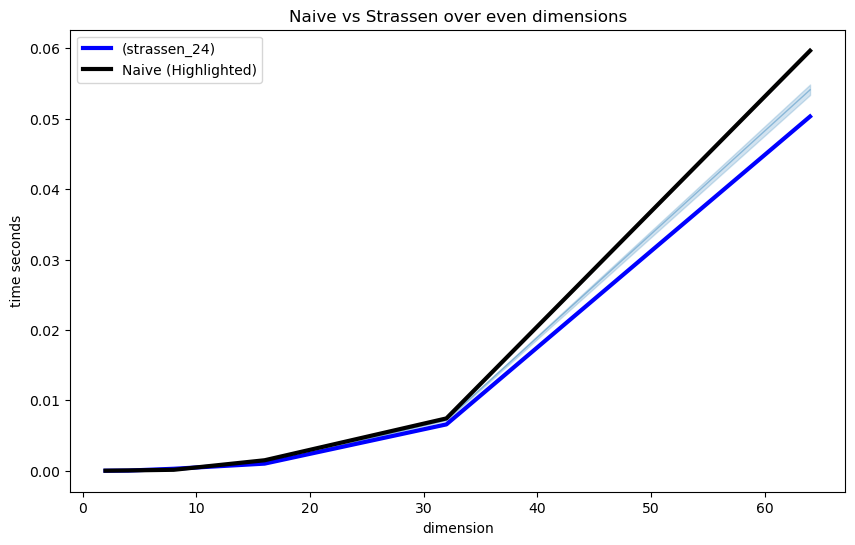

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the dataframe
df_melted = df.melt(id_vars="dimension", var_name="method", value_name="time")

# Filter out dimensions greater than 10
df_filtered = df_melted[df_melted["dimension"] > 8]

# Find the method with the lowest average time after dimension 10
lowest_method = df_filtered.groupby("method")["time"].mean().idxmin()

# Create the plot
plt.figure(figsize=(10, 6))

# Plot all methods with lower opacity
sns.lineplot(data=df_melted, x="dimension", y="time", alpha=0.4, linewidth=1)

# Highlight the method with the lowest time after dimension 10
sns.lineplot(
    data=df_melted[df_melted["method"] == lowest_method], 
    x="dimension", 
    y="time", 
    color="blue", 
    linewidth=3, 
    label=f"({lowest_method})"
)

sns.lineplot(
    data=df_melted[df_melted["method"] == "naive_time"], 
    x="dimension", 
    y="time", 
    color="black", 
    linewidth=3, 
    label="Naive (Highlighted)"
)


# Show the plot
plt.legend()
plt.title("Naive vs Strassen over even dimensions")
plt.ylabel("time seconds")
plt.show()

/Users/devinguevara/micromamba/envs/cs109b/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/devinguevara/micromamba/envs/cs109b/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/devinguevara/micromamba/envs/cs109b/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_

<Axes: xlabel='dimension', ylabel='time'>

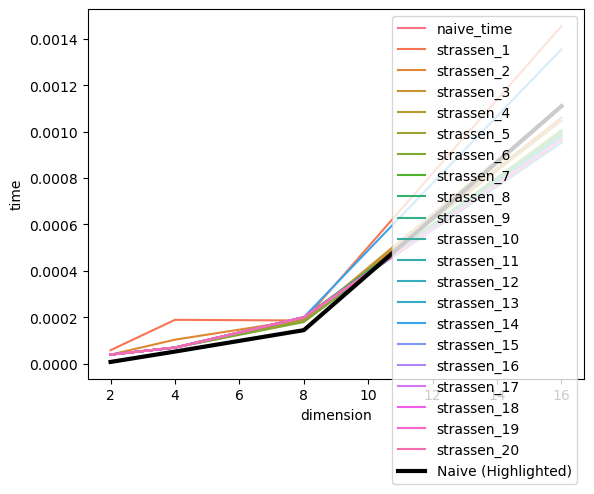

In [ ]:
df_melted = df.melt(id_vars="dimension", var_name="method", value_name="time")
sns.lineplot(data=df_melted, x="dimension", y="time", hue="method")

sns.lineplot(
    data=df_melted[df_melted["method"] == "naive_time"], 
    x="dimension", 
    y="time", 
    color="black", 
    linewidth=3, 
    label="Naive (Highlighted)"
)



### TRYING IT MY WAY!

In [140]:

def strassen(A, B):
    dim = A.shape[0]
    
    if dim == 1:
        return matrix_mult(A, B)
    
    #make sure ur putting the right n in there for example 
    newDim = dim // 2
    
    #split up matrices 
    a, b, c, d = A[:newDim, :newDim], A[:newDim, newDim:], A[newDim:, :newDim], A[newDim:, newDim:]
    e, f, g, h = B[:newDim, :newDim], B[:newDim, newDim:], B[newDim:, :newDim], B[newDim:, newDim:]

    #do 7 multiplications 
    p1 = matrix_mult(a, add_subtract_matrix(f, h, -1))
    p2 = matrix_mult(add_subtract_matrix(a, b), h)
    p3 = matrix_mult(add_subtract_matrix(c, d), e)
    p4 = matrix_mult(d, add_subtract_matrix(g, e, -1))
    p5 = matrix_mult(add_subtract_matrix(a, d), add_subtract_matrix(e, h))
    p6 = matrix_mult(add_subtract_matrix(b, d, -1), add_subtract_matrix(g, h))
    p7 = matrix_mult(add_subtract_matrix(c, a, -1), add_subtract_matrix(e, f))
    
    #AE + BG = -p2 + p4 + p5 + p6
    C11 = add_subtract_matrix(add_subtract_matrix(p4, p2, -1), add_subtract_matrix(p6, p5))

    #AF + BH = p1 + p2
    C12 = add_subtract_matrix(p1, p2)

    #CE + DG = p3 + p4
    C21 = add_subtract_matrix(p3, p4)

    #CF + DH = p1 - p3 + p5 + p7
    C22 = add_subtract_matrix(add_subtract_matrix(p1, p3, -1), add_subtract_matrix(p5, p7))
    
    #construct result matrix using numpy
    C = np.block([[C11, C12], [C21, C22]])

    
    return C

def strassen_pad(A, B, n):

    dim = A.shape[0]
   
    if (dim % 2 == 1): 

        newDim = dim + 1
    
        A_padded = np.pad(A, ((0, newDim - dim), (0, newDim - dim)), mode='constant')
        B_padded = np.pad(B, ((0, newDim - dim), (0, newDim - dim)), mode='constant')
    
        C_padded = strassen(A_padded, B_padded, n)
        return C_padded[:dim, :dim]
    else: 
        return strassen(A, B, n)
    

def gendata(d): 

    #generate random matrices A and B 
    A, B = generate_random_matrix(d), generate_random_matrix(d)

    #find the time it takes to run naive multiplication 
    start = time.time()
    matrix_mult(A, B)
    end = time.time()
    naive_time = end - start

    #find the time it takes to run strassen for every possible cut off
    start= time.time()
    strassen(A, B) 
    end = time.time()
    strassen_time = (end - start)

    return naive_time, strassen_time


def find_cutoff(d, odd=False):  
   
    if odd:
        dimensions = list(range(1, d + 1, 2))  
    else:
        dimensions = list(range(2, d + 1, 2))

    columns = ['dimension', 'naive_time', 'strassen_time']
    df = pd.DataFrame(columns=columns)

    for dim in dimensions:
        
        naive_time, strassen_time = gendata(dim)

        row = {'dimension': dim, 'naive_time': naive_time, 'strassen_time': strassen_time}

        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


    return df  


In [ ]:
df = find_cutoff(40, odd = False)


import matplotlib.pyplot as plt

# Assuming df is already defined
df_melted = df.melt(id_vars="dimension", var_name="method", value_name="time")

# Create the line plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_melted, x="dimension", y="time", hue="method", marker="o")

# Label the axes and title
plt.xlabel("Matrix Dimension")
plt.ylabel("Time (seconds)")
plt.title("Naive vs Strassen Multiplication Time")
plt.legend(title="Method")

# Show the plot
plt.show()


/var/folders/j4/zj28bjxn54q3hjjsq0wlg3sr0000gn/T/ipykernel_30807/1332431019.py:94: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


,dimension,naive_time,strassen_time
0,2,0.000013,0.000115
1,4,0.000045,0.000160
2,6,0.000145,0.000380
3,8,0.000263,0.000391
4,10,0.000806,0.000597


<Axes: >

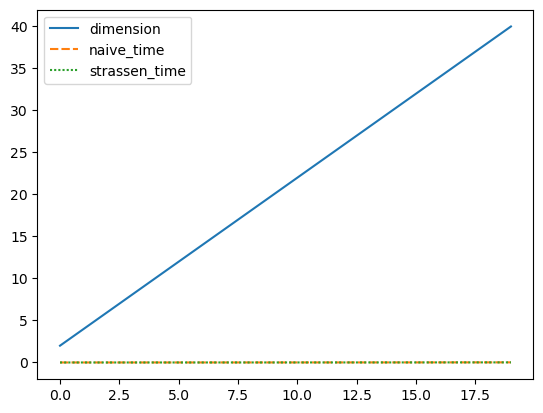

In [142]:
sns.lineplot(data=df)